# Part 4

#(a) Closed-Form Ruin Probability

## The Setup

We model inventory as a **biased random walk** on integers {-L, ..., 0, ..., +U}
where L = U = 40.

- Each step: inventory goes +1 or -1
- At i = 0: symmetric, Pr[+1] = Pr[-1] = 0.5
- At i ≠ 0: biased towards the nearest barrier with probability p = 0.515
- q = 1 - p = 0.485 (probability of stepping back toward zero)

The session ends with:
- **RUIN**: If inventory hits +U or -U (absorbed at barrier)
- **SAFE**: T = 10 round-trips gets completed before hitting any barrier

## Step 1: Focus on One Round-Trip

A **round-trip** = one excursion away from 0 that returns to 0.

By symmetry, WLOG assume first step lands at **+1**.

Once at +1, the walk has:
- p = 0.515 toward **+U** (ruin)
- q = 0.485 toward **0** (safe, round-trip complete)

So, **-U cannot be reached** during this excursion, the walk would have to
cross 0 first, which ends the round-trip. So each excursion only risks one barrier.

This is now a classic **Gambler's Ruin** problem:
- Starting at position k=1, biased walk with absorbing barriers at 0 and N=U.

## Step 2: Gambler's Ruin Formula

For a biased random walk starting at position k,
with absorbing barriers at 0 and N:

$$P(\text{hit } N \text{ before } 0 \mid \text{start at } k) = \frac{1 - (q/p)^k}{1 - (q/p)^N}$$

In our case k = 1, N = U = 40:

$$r = \frac{1 - (q/p)^1}{1 - (q/p)^{40}} = \frac{1 - (q/p)}{1 - (q/p)^{40}}$$

where r is the **per-round-trip ruin probability**.

## Step 3: Combine T Round-Trips

Each round-trip starts fresh at i = 0 => round-trips are **independent**

Therefore:

$$P(\text{survive one trip}) = 1 - r$$

$$P(\text{survive all T trips}) = (1-r)^T$$

$$\boxed{P(\text{ruin in session}) = 1 - (1-r)^T}$$

## Final Closed-Form Answer

Substituting r:

$$\boxed{P(\text{ruin}) = 1 - \left(1 - \frac{1 - (q/p)}{1 - (q/p)^{U}}\right)^{T}}$$

where:
- $p = 0.515$ (adverse selection probability, estimated from Monday's data)
- $q = 1 - p = 0.485$
- $U = 40$ (barrier distance)
- $T = 10$ (round-trips needed to complete session safely)

In [1]:
p = 0.515
q = 1 - p
U = 40
T = 10

# per round-trip ruin probability (Gambler's Ruin)
ratio = q / p
r = (1 - ratio) / (1 - ratio**U)

# full session ruin probability
ruin_session = 1 - (1 - r)**T

print(f"q/p ratio           = {ratio:.6f}")
print(f"Per-trip ruin r     = {r:.8f}")
print(f"P(ruin in session)  = {ruin_session:.8f}")
print(f"In percentage       = {ruin_session*100:.4f}%")

q/p ratio           = 0.941748
Per-trip ruin r     = 0.06405960
P(ruin in session)  = 0.48419927
In percentage       = 48.4199%


# (b) Sensitivity and Intuition

From part (a), the session ruin probability is:

$$P(\text{ruin}) = 1 - \left(1 - \frac{1 - (q/p)}{1 - (q/p)^{U}}\right)^{T}$$

The key quantity inside is the **ratio** $\rho = q/p$.

- When p = 0.5 exactly => ρ = 1 and walk is **symmetric**, no bias
- When p > 0.5 => ρ < 1 and walk is **biased toward barrier**, more ruin risk
- When p < 0.5 => ρ > 1 and walk is **biased away from barrier**, less ruin risk

### Reason for curve being steep near p = 0.5:

At p = 0.5 (symmetric walk), the Gambler's Ruin formula has a special limit:

$$r = \lim_{p \to 0.5} \frac{1-(q/p)}{1-(q/p)^U} = \frac{1}{U}$$

This is because when ρ approaches 1, both numerator and denominator approaces 0, and by L'Hopital's rule the limit is 1/U = 1/40 = 0.025.

Now when p increases even slightly above 0.5:
- ρ = q/p drops below 1
- The numerator (1 - ρ) grows
- But the denominator (1 - ρ^U) grows much **slower** because ρ^U is still close to 1
  when ρ is close to 1
- So r increases **disproportionately fast**

So, when the walk is nearly fair (p ≈ 0.5), even a tiny adverse edge compounds across thousands of steps and each step slightly favors the barrier, and over a long excursion these tiny nudges accumulate rapidly. The barrier at ±40 is far away, but a biased walk reaches it far more often than a fair walk would, and this effect is highly nonlinear near the fair-coin boundary."

## Finding p*

We want to solve:

$$1 - \left(1 - \frac{1-(q/p)}{1-(q/p)^U}\right)^T = 0.5$$

We solve it numerically using binary search (bisection method).

The bisection method:
- Start with a range [low, high] where ruin prob crosses 0.5
- Repeatedly halve the interval, keeping the half where the crossing occurs
- Converge to p* with arbitrary precision

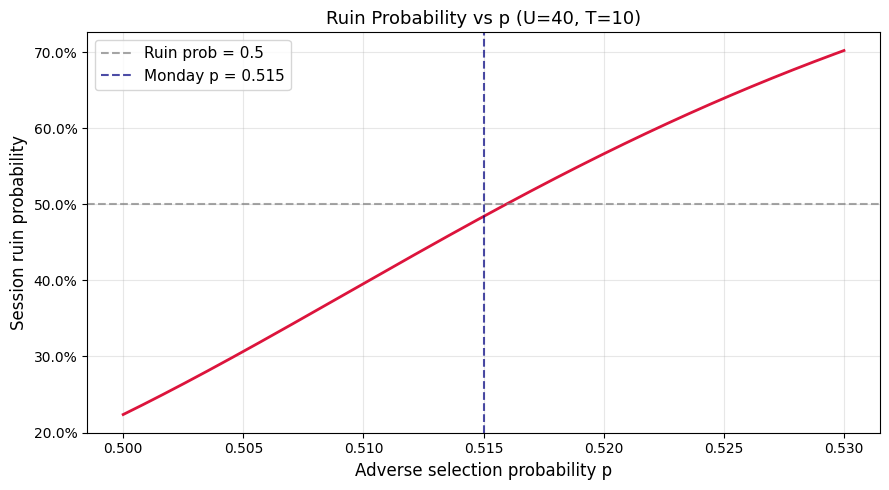

p* (ruin prob = 50%) = 0.515924
Verification: ruin_prob(p*) = 0.500000
Note: p* = 0.515924 falls INSIDE the plotted range [0.500, 0.530]

For Monday's p = 0.515:
Ruin probability = 48.4199%


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
U = 40
T = 10

def ruin_prob(p, U=40, T=10):
    q = 1 - p
    if abs(p - 0.5) < 1e-10:
        # limit of Gambler's Ruin as p approaches 0.5 (L'Hopital's rule)
        r = 1 / U
    else:
        ratio = q / p
        r = (1 - ratio) / (1 - ratio**U)
    return 1 - (1 - r)**T

# Plot: ruin probability vs p over [0.500, 0.530]
p_vals = np.linspace(0.500, 0.530, 1000)
ruin_vals = [ruin_prob(p) for p in p_vals]

plt.figure(figsize=(9, 5))
plt.plot(p_vals, ruin_vals, color='crimson', linewidth=2)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Ruin prob = 0.5')
plt.axvline(x=0.515, color='navy', linestyle='--', alpha=0.7, label='Monday p = 0.515')
plt.xlabel('Adverse selection probability p', fontsize=12)
plt.ylabel('Session ruin probability', fontsize=12)
plt.title('Ruin Probability vs p (U=40, T=10)', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
plt.tight_layout()
plt.show()

# Find p* using bisection
low, high = 0.500, 0.600
tolerance = 1e-10

while (high - low) > tolerance:
    mid = (low + high) / 2
    if ruin_prob(mid) < 0.5:
        low = mid      # p* is in upper half
    else:
        high = mid     # p* is in lower half

p_star = (low + high) / 2

print(f"p* (ruin prob = 50%) = {p_star:.6f}")
print(f"Verification: ruin_prob(p*) = {ruin_prob(p_star):.6f}")

if p_star > 0.530:
    print(f"Note: p* = {p_star:.6f} falls OUTSIDE the plotted range [0.500, 0.530]")
else:
    print(f"Note: p* = {p_star:.6f} falls INSIDE the plotted range [0.500, 0.530]")

print(f"\nFor Monday's p = 0.515:")
print(f"Ruin probability = {ruin_prob(0.515)*100:.4f}%")